# DSC 291 HW4

# Setup & Data Loading

## Config

In [ ]:
# Set AWS credentials for S3 access
# NOTE: Set these as environment variables before running the notebook:
# export AWS_ACCESS_KEY_ID=your_key
# export AWS_SECRET_ACCESS_KEY=your_secret
# export AWS_SESSION_TOKEN=your_token
# Or use: aws configure
import os

# Paths (edit for your environment)
RAW_PARQUET_PATH = "s3://dsc291-ucsd/taxi"
PIVOT_PARQUET_PATH = "s3://291-s3-bucket/wide.parquet"

MAX_ROWS_PER_CLASS = 50_000  # set to None for all rows
RANDOM_SEED = 42
TRAIN_FRAC = 0.80

print("RAW_PARQUET_PATH ", RAW_PARQUET_PATH)
print("PIVOT_PARQUET_PATH", PIVOT_PARQUET_PATH)
print("MAX_ROWS_PER_CLASS", MAX_ROWS_PER_CLASS)
print("RANDOM_SEED", RANDOM_SEED)
print("TRAIN_FRAC", TRAIN_FRAC)

RAW_PARQUET_PATH  s3://dsc291-ucsd/taxi
PIVOT_PARQUET_PATH s3://291-s3-bucket/wide.parquet
MAX_ROWS_PER_CLASS 50000
RANDOM_SEED 42
TRAIN_FRAC 0.8


## Discovery + schema normalization

> **Note:** We restrict Part A to **yellow** and **green** taxi types only. FHV (for-hire vehicle) files use a substantially different schema (no `trip_distance`, `fare_amount`, etc.) and are excluded from classification.

In [2]:
import os
import re
from typing import Iterable, List

import dask.dataframe as dd
import fsspec
import pandas as pd

YELLOW_RE = re.compile(r"yellow[_-]tripdata", re.IGNORECASE)
GREEN_RE = re.compile(r"green[_-]tripdata", re.IGNORECASE)


def _get_fs_and_pattern(root):
    if root.startswith("s3://"):
        # Pass AWS credentials explicitly to fsspec
        storage_options = {
            "key": os.getenv("AWS_ACCESS_KEY_ID"),
            "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
            "token": os.getenv("AWS_SESSION_TOKEN"),
        }
        # Remove None values
        storage_options = {k: v for k, v in storage_options.items() if v is not None}
        fs = fsspec.filesystem("s3", **storage_options)
        _, _, bare = root.partition("s3://")
        pattern = bare.rstrip("/") + "/**/*.parquet"
        prefix = "s3://"
    else:
        fs = fsspec.filesystem("file")
        pattern = os.path.join(root, "**", "*.parquet")
        prefix = ""
    return fs, pattern, prefix


def discover_trip_files(root):
    """Return (yellow_files, green_files) as sorted lists of full paths.

    `root` may be a directory (recursively globs for .parquet) **or** a single
    .parquet file path (classified by filename).
    """
    # Single-file shortcut: if path ends with .parquet, classify directly
    if root.rstrip("/").endswith(".parquet"):
        fname = os.path.basename(root)
        if YELLOW_RE.search(fname):
            return [root], []
        if GREEN_RE.search(fname):
            return [], [root]
        return [root], []  # unknown type → treat as yellow for safety

    fs, pattern, prefix = _get_fs_and_pattern(root)
    candidates = fs.glob(pattern)
    yellow_files, green_files = [], []
    for p in candidates:
        fname = os.path.basename(p)
        full = prefix + p
        if YELLOW_RE.search(fname):
            yellow_files.append(full)
        elif GREEN_RE.search(fname):
            green_files.append(full)
    yellow_files.sort()
    green_files.sort()
    return yellow_files, green_files


_CANONICAL_VARIANTS = {
    "pickup_datetime": ["tpep_pickup_datetime", "lpep_pickup_datetime", "trip_pickup_datetime", "pickup_datetime"],
    "dropoff_datetime": ["tpep_dropoff_datetime", "lpep_dropoff_datetime", "trip_dropoff_datetime", "dropoff_datetime"],
    "trip_distance": ["trip_distance", "trip_miles"],
    "passenger_count": ["passenger_count"],
    "fare_amount": ["fare_amount", "fare_amt"],
}


def normalize_trip_schema(ddf):
    """Rename columns to pickup_datetime, dropoff_datetime, trip_distance, passenger_count, fare_amount."""
    cols = list(ddf.columns)
    lower_to_orig = {c.lower(): c for c in cols}
    rename = {}
    for canonical, variants in _CANONICAL_VARIANTS.items():
        for v in variants:
            if v.lower() in lower_to_orig:
                rename[lower_to_orig[v.lower()]] = canonical
                break
    ddf2 = ddf.rename(columns=rename)
    required = {"pickup_datetime", "dropoff_datetime", "trip_distance", "passenger_count", "fare_amount"}
    missing = required - set(ddf2.columns)
    if missing:
        raise KeyError(f"Missing required columns after normalization: {missing}")
    return ddf2

## Load + sample per class → df_partA

In [3]:
def _load_single_file_to_pandas(path, taxi_type, max_rows, random_state):
    # Pass AWS credentials for S3 access
    storage_options = None
    if path.startswith("s3://"):
        storage_options = {
            "key": os.getenv("AWS_ACCESS_KEY_ID"),
            "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
            "token": os.getenv("AWS_SESSION_TOKEN"),
        }
        storage_options = {k: v for k, v in storage_options.items() if v is not None}
    ddf = dd.read_parquet(path, engine="pyarrow", storage_options=storage_options)
    ddf = normalize_trip_schema(ddf)
    ddf = ddf[["pickup_datetime", "dropoff_datetime", "trip_distance", "passenger_count", "fare_amount"]]
    ddf = ddf.assign(taxi_type=taxi_type)

    pdf = ddf.compute()

    # Ensure datetime dtype for feature derivation
    pdf["pickup_datetime"] = pd.to_datetime(pdf["pickup_datetime"], errors="coerce")
    pdf["dropoff_datetime"] = pd.to_datetime(pdf["dropoff_datetime"], errors="coerce")

    # Required derived columns (HW4.2 Part A.2)
    pdf["trip_duration_min"] = (pdf["dropoff_datetime"] - pdf["pickup_datetime"]).dt.total_seconds() / 60.0
    pdf["hour"] = pdf["pickup_datetime"].dt.hour
    pdf["day_of_week"] = pdf["pickup_datetime"].dt.dayofweek

    # Drop missing/invalid values (HW4.2 Part A.2)
    pdf = pdf.dropna(
        subset=[
            "pickup_datetime",
            "dropoff_datetime",
            "trip_distance",
            "passenger_count",
            "trip_duration_min",
            "hour",
            "day_of_week",
        ]
    )
    pdf = pdf[(pdf["trip_distance"] > 0) & (pdf["trip_duration_min"] > 0)]

    # Sample per class so notebook runs quickly
    if max_rows is not None and len(pdf) > max_rows:
        pdf = pdf.sample(n=max_rows, random_state=random_state)

    pdf = pdf.reset_index(drop=True)
    return pdf


def load_partA_trip_sample(root=None, max_rows_per_class=None, random_state=RANDOM_SEED):
    if root is None:
        root = RAW_PARQUET_PATH
    if max_rows_per_class is None:
        max_rows_per_class = MAX_ROWS_PER_CLASS

    yellow_files, green_files = discover_trip_files(root)
    if not yellow_files or not green_files:
        raise RuntimeError(
            f"Need both yellow and green files under {root}; yellow={len(yellow_files)}, green={len(green_files)}"
        )

    yellow_path, green_path = yellow_files[0], green_files[0]
    print(f"[Part A] yellow: {yellow_path}")
    print(f"[Part A] green:  {green_path}")

    df_yellow = _load_single_file_to_pandas(
        yellow_path, "yellow", max_rows_per_class, random_state
    )
    df_green = _load_single_file_to_pandas(
        green_path, "green", max_rows_per_class, random_state + 1
    )

    df = pd.concat([df_yellow, df_green], ignore_index=True)
    print(f"[Part A] Yellow rows (post-clean): {len(df_yellow):,}")
    print(f"[Part A] Green  rows (post-clean): {len(df_green):,}")
    print(f"[Part A] Combined (post-clean): {len(df):,}")

    return df


df_partA = load_partA_trip_sample()
df_partA[[
    "trip_distance",
    "trip_duration_min",
    "hour",
    "day_of_week",
    "passenger_count",
    "taxi_type",
]].head()

[Part A] yellow: s3://dsc291-ucsd/taxi/Dataset/2009/yellow_taxi/yellow_tripdata_2009-01.parquet
[Part A] green:  s3://dsc291-ucsd/taxi/Dataset/2014/green_taxi/green_tripdata_2014-01.parquet
[Part A] Yellow rows (post-clean): 50,000
[Part A] Green  rows (post-clean): 50,000
[Part A] Combined (post-clean): 100,000


,trip_distance,trip_duration_min,hour,day_of_week,passenger_count,taxi_type
0,0.80,5.033333,21,4,2,yellow
1,3.00,6.716667,1,6,1,yellow
2,0.56,1.000000,3,3,1,yellow
3,6.60,28.650000,14,1,3,yellow
4,1.32,13.000000,14,4,1,yellow


In [4]:
# Inspect columns for Part A feature engineering
print("Columns in df_partA:")
print(df_partA.columns.tolist())
print()
print("Preview of df_partA:")
df_partA.head()

Columns in df_partA:
['pickup_datetime', 'dropoff_datetime', 'trip_distance', 'passenger_count', 'fare_amount', 'taxi_type', 'trip_duration_min', 'hour', 'day_of_week']

Preview of df_partA:


,pickup_datetime,dropoff_datetime,trip_distance,passenger_count,fare_amount,taxi_type,trip_duration_min,hour,day_of_week
0,2009-01-09 21:27:14,2009-01-09 21:32:16,0.80,2,5.4,yellow,5.033333,21,4
1,2009-01-18 01:12:32,2009-01-18 01:19:15,3.00,1,9.0,yellow,6.716667,1,6
2,2009-01-08 03:41:00,2009-01-08 03:42:00,0.56,1,3.7,yellow,1.000000,3,3
3,2009-01-13 14:04:12,2009-01-13 14:32:51,6.60,3,20.5,yellow,28.650000,14,1
4,2009-01-09 14:55:00,2009-01-09 15:08:00,1.32,1,8.1,yellow,13.000000,14,4


In [6]:
# Part A: XGBoost classifier on engineered features

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Features and target
feature_cols = [
    "trip_distance",
    "trip_duration_min",
    "hour",
    "day_of_week",
    "passenger_count",
]

target_col = "taxi_type"  # classify yellow vs green

X = df_partA[feature_cols]
y = df_partA[target_col]

# Encode string labels to integers for XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_encoded,
    test_size=1 - TRAIN_FRAC,
    random_state=RANDOM_SEED,
    stratify=y_encoded,
)

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    tree_method="hist",
)

xgb.fit(X_train, y_train)

y_pred_encoded = xgb.predict(X_valid)
y_pred = label_encoder.inverse_transform(y_pred_encoded)
y_valid_labels = label_encoder.inverse_transform(y_valid)

print("Accuracy:", accuracy_score(y_valid_labels, y_pred))
print()
print(classification_report(y_valid_labels, y_pred))

Accuracy: 0.77235

              precision    recall  f1-score   support

       green       0.77      0.79      0.78     10000
      yellow       0.78      0.76      0.77     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



max_depth=3: accuracy=0.7316
max_depth=5: accuracy=0.7674
max_depth=7: accuracy=0.7766
max_depth=9: accuracy=0.7790


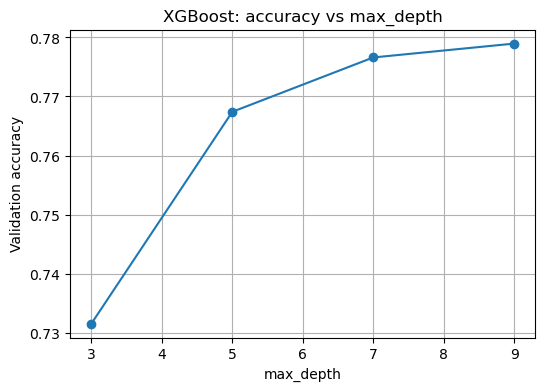

learning_rate=0.01: accuracy=0.6802
learning_rate=0.05: accuracy=0.7512
learning_rate=0.1: accuracy=0.7723
learning_rate=0.2: accuracy=0.7794


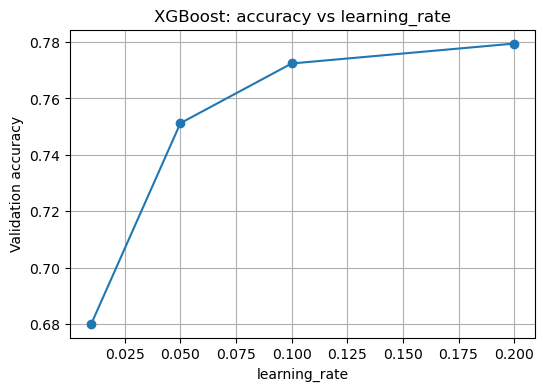

In [7]:
# Extra credit: hyperparameter study (max_depth and learning_rate)

import matplotlib.pyplot as plt

depths = [3, 5, 7, 9]
acc_depths = []

for d in depths:
    model = XGBClassifier(
        objective="multi:softmax",
        num_class=len(label_encoder.classes_),
        max_depth=d,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        tree_method="hist",
    )
    model.fit(X_train, y_train)
    y_pred_d_encoded = model.predict(X_valid)
    y_pred_d = label_encoder.inverse_transform(y_pred_d_encoded)
    acc = accuracy_score(y_valid_labels, y_pred_d)
    acc_depths.append(acc)
    print(f"max_depth={d}: accuracy={acc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(depths, acc_depths, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Validation accuracy")
plt.title("XGBoost: accuracy vs max_depth")
plt.grid(True)
plt.show()

etas = [0.01, 0.05, 0.1, 0.2]
acc_etas = []

for eta in etas:
    model = XGBClassifier(
        objective="multi:softmax",
        num_class=len(label_encoder.classes_),
        max_depth=6,
        learning_rate=eta,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        tree_method="hist",
    )
    model.fit(X_train, y_train)
    y_pred_eta_encoded = model.predict(X_valid)
    y_pred_eta = label_encoder.inverse_transform(y_pred_eta_encoded)
    acc = accuracy_score(y_valid_labels, y_pred_eta)
    acc_etas.append(acc)
    print(f"learning_rate={eta}: accuracy={acc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(etas, acc_etas, marker="o")
plt.xlabel("learning_rate")
plt.ylabel("Validation accuracy")
plt.title("XGBoost: accuracy vs learning_rate")
plt.grid(True)
plt.show()

## Pivot schema + pickup_region (extra credit)

In [8]:
def _normalize_pivot_schema(ddf):
    """Normalize pivoted wide table columns.

    Accepts either explicit columns (taxi_type, date, pickup_place/pickup_location) or
    Parquet-stored index columns (commonly named __index_level_0__, __index_level_1__, ...).
    """

    cols = list(ddf.columns)

    # If the wide table was written with a MultiIndex, Parquet readers sometimes surface
    # the index as __index_level_0__, __index_level_1__, __index_level_2__.
    index_level_cols = [c for c in cols if re.fullmatch(r"__index_level_\d+__", str(c))]
    if "taxi_type" not in cols and len(index_level_cols) >= 3:
        def _level_num(name: str) -> int:
            return int(re.findall(r"\d+", name)[0])

        il = sorted((str(c) for c in index_level_cols), key=_level_num)
        ddf = ddf.rename(columns={il[0]: "taxi_type", il[1]: "date", il[2]: "pickup_place"})
        cols = list(ddf.columns)

    # Taxi type variants
    if "taxi_type" not in cols:
        for c in ("taxi", "cab_type", "service_type", "taxitype"):
            if c in cols:
                ddf = ddf.rename(columns={c: "taxi_type"})
                cols = list(ddf.columns)
                break

    # Date variants
    if "date" not in cols:
        for c in ("pickup_date", "trip_date", "service_date", "day"):
            if c in cols:
                ddf = ddf.rename(columns={c: "date"})
                cols = list(ddf.columns)
                break

    # Location variants
    loc_col = None
    for c in (
        "pickup_location",
        "pickup_place",
        "PULocationID",
        "PULocationId",
        "PUlocationID",
        "pulocationid",
    ):
        if c in cols:
            loc_col = c
            break

    if loc_col is not None and loc_col != "pickup_location":
        ddf = ddf.rename(columns={loc_col: "pickup_location"})
        cols = list(ddf.columns)

    hour_cols = [c for c in cols if str(c).startswith("hour_")]

    missing = []
    if "taxi_type" not in cols:
        missing.append("taxi_type")
    if "date" not in cols:
        missing.append("date")
    if "pickup_location" not in cols:
        missing.append("pickup_location")
    if not hour_cols:
        missing.append("hour_0..hour_23")

    if missing:
        preview = cols[:50]
        suffix = "..." if len(cols) > 50 else ""
        raise KeyError(f"Pivoted data missing required fields {missing}. Columns seen: {preview}{suffix}")

    return ddf


def _pickup_region(pu):
    try:
        z = int(pu)
    except (TypeError, ValueError):
        return "other"
    if 1 <= z <= 100:
        return "core_manhattan"
    if 101 <= z <= 200:
        return "outer_boroughs"
    if 201 <= z <= 300:
        return "airports_and_bridges"
    return "other"

## Load pivoted parquet + date & region → pivot_df (extra credit)

In [9]:
def load_pivot_with_extras(path=None):
    if path is None:
        path = PIVOT_PARQUET_PATH
    print(f"[Part B] Reading: {path}")

    # Primary path: Dask (fast / scalable)
    try:
        # Key detail: when Parquet was written with a pandas index=True,
        # Dask may treat those index columns as index metadata and not expose them in ddf.columns.
        # index=False forces Dask to keep everything as normal columns.
        ddf = dd.read_parquet(path, engine="pyarrow", index=False)
        ddf = _normalize_pivot_schema(ddf)

        ddf = ddf[ddf["taxi_type"].isin(["yellow", "green"])]
        ddf["date"] = dd.to_datetime(ddf["date"])
        ddf["year"] = ddf["date"].dt.year
        ddf["month"] = ddf["date"].dt.month
        ddf["day_of_week"] = ddf["date"].dt.dayofweek
        ddf["pickup_region"] = ddf["pickup_location"].map_partitions(
            lambda s: s.map(_pickup_region),
            meta=("pickup_region", "object"),
        )

        pivot_df = ddf.compute()
        print(f"[Part B] Rows (yellow+green): {len(pivot_df):,}")
        return pivot_df

    except KeyError as e:
        # Common case: Parquet contains a MultiIndex (taxi_type/date/pickup_place)
        # stored in pandas metadata; Dask may only show hour_* columns.
        print(f"[Part B] Dask schema normalize failed ({e}). Falling back to pandas...")

        pdf = pd.read_parquet(path, engine="pyarrow")

        # If index carries the key columns, bring them back as columns.
        if isinstance(pdf.index, pd.MultiIndex):
            pdf = pdf.reset_index()
        elif pdf.index.name is not None:
            pdf = pdf.reset_index()

        pdf = _normalize_pivot_schema(pdf)

        pdf = pdf[pdf["taxi_type"].isin(["yellow", "green"])].copy()
        pdf["date"] = pd.to_datetime(pdf["date"])
        pdf["year"] = pdf["date"].dt.year
        pdf["month"] = pdf["date"].dt.month
        pdf["day_of_week"] = pdf["date"].dt.dayofweek
        pdf["pickup_region"] = pdf["pickup_location"].map(_pickup_region)

        print(f"[Part B] Rows (yellow+green): {len(pdf):,}")
        return pdf


pivot_df = load_pivot_with_extras()
pivot_df.head()

[Part B] Reading: s3://291-s3-bucket/wide.parquet
[Part B] Rows (yellow+green): 2,053,698


,taxi_type,date,pickup_location,hour_0,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,...,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,year,month,day_of_week,pickup_region
0,yellow,2009-01-01,-73.137_41.366,60,67,57,44,25,20,6,...,43,36,41,43,41,18,2009,1,3,other
1,yellow,2009-01-01,-73.777_40.645,4,2,1,0,0,10,12,...,38,72,46,46,60,28,2009,1,3,other
2,yellow,2009-01-01,-73.777_40.646,3,1,0,0,0,1,2,...,2,2,9,7,4,5,2009,1,3,other
3,yellow,2009-01-01,-73.781_40.645,3,0,0,0,0,0,0,...,3,1,7,4,4,10,2009,1,3,other
4,yellow,2009-01-01,-73.782_40.645,22,20,9,6,0,5,15,...,47,35,33,18,40,54,2009,1,3,other
